In [ ]:
# import os
# os.environ["KAGGLE_CONFIG_DIR"] = "C:\Users\****\.kaggle\kaggle.json"

In [ ]:
# import os

# os.environ['KAGGLE_USERNAME'] = ''
# os.environ['KAGGLE_KEY'] = ''

In [1]:
# !kaggle datasets download -d arunjangir245/german-credit-card

Dataset URL: https://www.kaggle.com/datasets/arunjangir245/german-credit-card
License(s): DbCL-1.0




  0%|          | 0.00/19.2k [00:00<?, ?B/s]
100%|##########| 19.2k/19.2k [00:00<?, ?B/s]


In [3]:
# import zipfile

# with zipfile.ZipFile("german-credit-card.zip", "r") as zip_ref:
#     zip_ref.extractall("german-credit-card")

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
pd.set_option("display.max_columns", None)

In [9]:
sns.set(style="whitegrid", palette="pastel", font_scale=1)
plt.rcParams["figure.figsize"] = (5,3)

In [13]:
german = pd.read_csv("german-credit-card/GermanCredit.csv")

In [15]:
german.sample(5)

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
795,no checking account,9,existing credits paid back duly till now,radio/television,2301,100 <= ... < 500 DM,... < 1 year,2,female : divorced/separated/married,none,4,building society savings agreement/life insurance,22,none,rent,1,skilled employee/official,1,no,yes,1
485,0 <= ... < 200 DM,6,delay in paying off in the past,car (new),1209,... < 100 DM,unemployed,4,male : single,none,4,building society savings agreement/life insurance,47,none,own,1,management/self-employed/highly qualified empl...,1,yes,yes,0
669,... >= 200 DM / salary for at least 1 year,30,critical account/other credits existing,domestic appliances,3017,... < 100 DM,... >= 7 years,4,male : single,none,4,building society savings agreement/life insurance,47,none,own,1,skilled employee/official,1,no,yes,1
796,... < 100 DM,18,existing credits paid back duly till now,car (used),7511,unknown/no savings account,... >= 7 years,1,male : single,none,4,building society savings agreement/life insurance,51,none,for free,1,skilled employee/official,2,yes,yes,0
877,no checking account,36,existing credits paid back duly till now,domestic appliances,3595,... < 100 DM,... >= 7 years,4,male : single,none,2,car or other,28,none,own,1,skilled employee/official,1,no,yes,1


# Exploratory Data Analysis

In [18]:
df = german.copy()

### Feature Type Identification

In [54]:
X = df.drop(columns=["credit_risk"])
y = df["credit_risk"]
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"📋 Categorical Features ({len(cat_cols)}):")
print(cat_cols)
print(f"\n📊 Numerical Features ({len(num_cols)}):")
print(num_cols)

📋 Categorical Features (13):
['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

📊 Numerical Features (7):
['duration', 'amount', 'installment_rate', 'present_residence', 'age', 'number_credits', 'people_liable']


### Descriptive Statis For Numerical Features

In [56]:
print("📊 Descriptive Statistics for Numerical Features:")
df[num_cols].describe().round(2)

📊 Descriptive Statistics for Numerical Features:


,duration,amount,installment_rate,present_residence,age,number_credits,people_liable
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00


### Distribution of Key Numerical Features

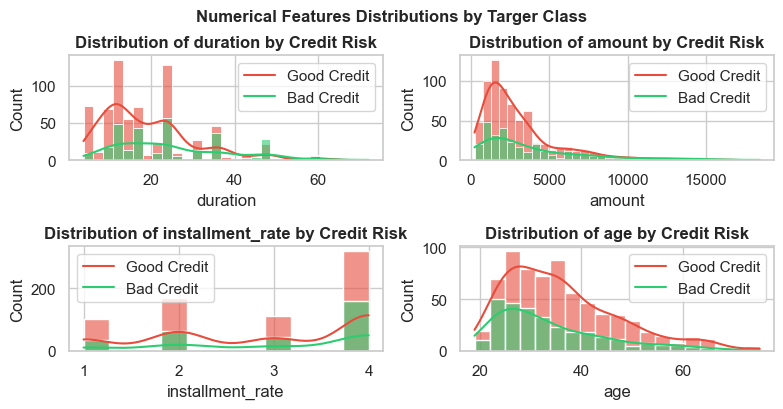

In [76]:
fig, axes = plt.subplots(2,2, figsize=(8,4))
key_features = ['duration', 'amount', 'installment_rate', 'age']

for idx, feature in enumerate(key_features):
    ax = axes[idx//2, idx%2]

    sns.histplot(data=df, x=feature, hue="credit_risk", kde=True, ax=ax,
                palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.6)
    ax.set_title(f"Distribution of {feature} by Credit Risk", fontsize=12, fontweight="bold")
    ax.legend(["Good Credit", "Bad Credit"])

plt.tight_layout()
plt.suptitle("Numerical Features Distributions by Targer Class", fontsize=12, fontweight="bold", y=1.02)
plt.show()

1. #### Duration_in_month (Represents: Length of the loan in months)
| Statistic                    | Meaning                                                                            |
| ---------------------------- | ---------------------------------------------------------------------------------- |
| **count = 10000**            | All 10,000 records have valid duration values.                                     |
| **mean = 38.11 months**      | Average loan duration is around 3.2 years.                                         |
| **std = 19.94**              | Very high spread — durations vary widely.                                          |
| **min = 4 months**           | Shortest loan is 4 months.                                                         |
| **25% = 21 months**          | 25% of loans are less than 21 months.                                              |
| **50% (median) = 38 months** | Half the loans are shorter than 38 months — same as mean → symmetric distribution. |
| **75% = 56 months**          | 25% are longer than 56 months.                                                     |
| **max = 72 months**          | Longest loan is 6 years.                                                           |
#### Interpretation: Loan durations vary widely. No severe outliers. MST distribution looks moderately spread from 1–6 years.

<Axes: xlabel='Duration_in_month', ylabel='Count'>

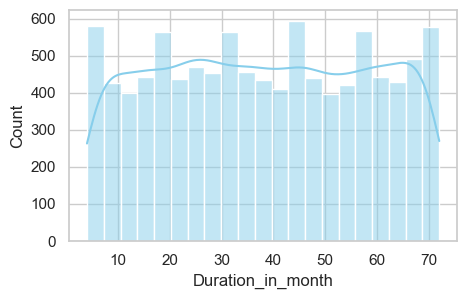

In [125]:
sns.histplot(data=df, x="Duration_in_month", kde=True, color="skyblue")

#### 2. Credit_amount (Represents: Loan amount taken)
| Statistic                    | Explanation                                          |
| ---------------------------- | ---------------------------------------------------- |
| **mean = 10.17 million PKR** | Average loan size is ~10.17M.                        |
| **std = 5.65M PKR**          | Huge variation — plenty of small and very big loans. |
| **min = 0.25M**              | Smallest loan is 250,000 PKR.                        |
| **25% = 5.32M**              | Lower 25% loans are small to medium.                 |
| **50% = 10.21M**             | Typical (median) loan is ~10M PKR.                   |
| **75% = 15.01M**             | Top 25% loans are larger than 15M PKR.               |
| **max = 20M**                | Biggest loan is 20,000,000 PKR.                      |
#### Interpretation: Very large spread → income and credit scoring models must normalize this. Distribution probably right-skewed (few very large loans).

<Axes: xlabel='Credit_amount', ylabel='Count'>

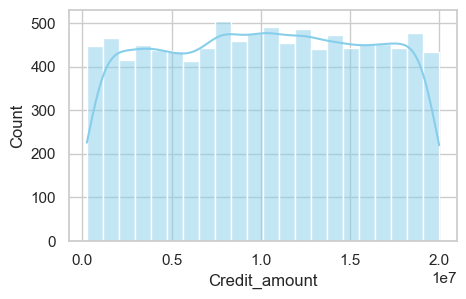

In [132]:
sns.histplot(data=df, x="Credit_amount", kde=True, color="skyblue")

#### 3. Installment_rate_percent_income (Represents what % of the borrower’s income is paid monthly as loan installment)
| Statistic         | Explanation                                     |
| ----------------- | ----------------------------------------------- |
| **mean = 2.505%** | Average person pays ~2.5% of income each month. |
| **std = 1.11**    | Some pay only 1%, others up to 4%.              |
| **min = 1%**      | Lowest installment burden.                      |
| **25% = 2%**      | Most people pay at least 2%.                    |
| **50% = 3%**      | Typical rate is 3%.                             |
| **75% = 4%**      | 25% pay the maximum allowed rate.               |
| **max = 4%**      | Dataset caps at 4%.                             |
#### Interpretation: This column is categorical-discrete (1,2,3,4). Higher values mean higher burden → more risk in credit scoring.

<Axes: xlabel='Installment_rate_percent_income', ylabel='Count'>

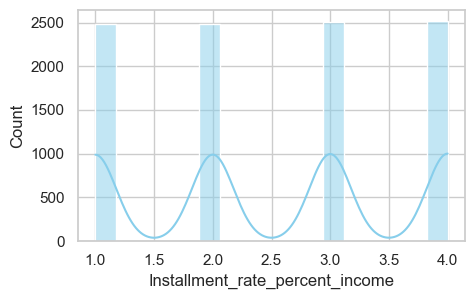

In [135]:
sns.histplot(data=df, x="Installment_rate_percent_income", kde=True, color="skyblue")

#### 4. Present_residence_since (Represents: How long (years) the borrower has lived at current residence)
Values from 1 to 4 → discrete category.
| Statistic             | Explanation                   |
| --------------------- | ----------------------------- |
| **mean = 2.49 years** | Average stay is ~2.5 years.   |
| **std = 1.12**        | Variation is moderate.        |
| **min = 1 year**      | Newly moved.                  |
| **25% = 1 year**      | Many have lived only 1 year.  |
| **50% = 2 years**     | Typical duration is 2.        |
| **75% = 4 years**     | Some are long-term residents. |
| **max = 4 years**     | Maximum category.             |
#### Interpretation: Stability indicator — people staying longer are usually lower risk.

<Axes: xlabel='Present_residence_since', ylabel='Count'>

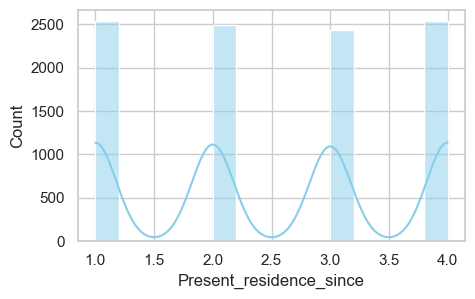

In [138]:
sns.histplot(data=df, x="Present_residence_since", kde=True, color="skyblue")

#### 5. Age_in_years (Represents: Borrower’s current age)
| Statistic              | Explanation                        |
| ---------------------- | ---------------------------------- |
| **mean = 46.78 years** | Average borrower is ~47 years old. |
| **std = 16.68**        | Age varies widely.                 |
| **min = 18**           | Youngest legal adult.              |
| **25% = 32**           | 25% are younger than 32.           |
| **50% = 47**           | Median age is 47.                  |
| **75% = 61**           | 25% are older than 61.             |
| **max = 75**           | Oldest is 75.                      |
#### Interpretation: Widely distributed. May affect risk scoring — very young and very old may carry different risk profiles.

<Axes: xlabel='Age_in_years', ylabel='Count'>

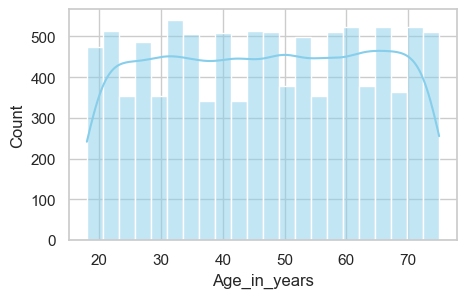

In [142]:
sns.histplot(data=df, x="Age_in_years", kde=True, color="skyblue")

#### 6. Number_of_existing_credits_at_this_bank (Represents: Loans already taken from the same bank)
Values: 1 to 4 (category type, not continuous)
| Statistic        | Explanation                                    |
| ---------------- | ---------------------------------------------- |
| **mean = 2.506** | Most customers have around 2–3 existing loans. |
| **std = 1.11**   | Spread is moderate.                            |
| **min = 1**      | At least 1 loan.                               |
| **25% = 2**      | 25% have 2 loans.                              |
| **50% = 3**      | Typical customer has 3 loans.                  |
| **75% = 4**      | Heavy borrowers.                               |
| **max = 4**      | Maximum category.                              |
#### Interpretation: Higher value → riskier because they already owe a lot

<Axes: xlabel='Number_of_existing_credits_at_this_bank', ylabel='Count'>

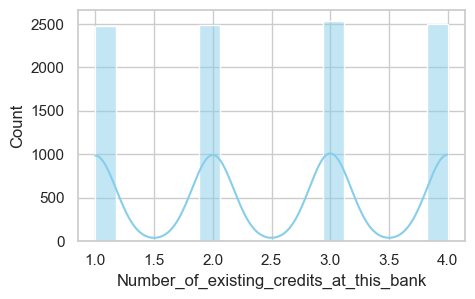

In [145]:
sns.histplot(data=df, x="Number_of_existing_credits_at_this_bank", kde=True, color="skyblue")

#### 7. Annual Income (PKR) (Represents: Borrower’s yearly income)
| Statistic             | Explanation                                                     |
| --------------------- | --------------------------------------------------------------- |
| **mean = 5.84M PKR**  | Average income ~5.8 million per year.                           |
| **std = 5.23M**       | Very high variation — some earn extremely high incomes.         |
| **min = 29,456 PKR**  | Very low salary (likely part-time or incorrect).                |
| **25% = 774,202 PKR** | Lower earners.                                                  |
| **50% = 6.1M PKR**    | Median is high (means some very high incomes pull the average). |
| **75% = 8.15M PKR**   | Top earners.                                                    |
| **max = 16.49M**      | Highest income in dataset.                                      |
#### Interpretation: Income distribution is highly skewed → scaling required. Min value looks suspicious (29k per year = 2,400 per month).

<Axes: xlabel='Annual Income (PKR)', ylabel='Count'>

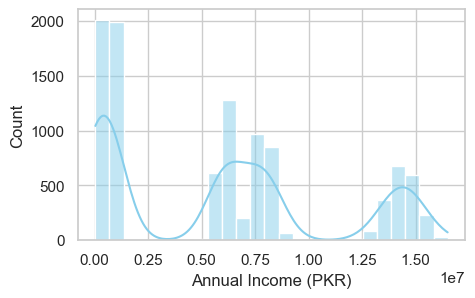

In [148]:
sns.histplot(data=df, x="Annual Income (PKR)", kde=True, color="skyblue")

#### 8. Number_of_people_liable_for_maintenance (Represents: People financially dependent on the borrower)
Values are 1 or 2.
| Statistic        | Explanation                          |
| ---------------- | ------------------------------------ |
| **mean = 1.495** | Most borrowers have ~1–2 dependents. |
| **std = 0.50**   | Expected for binary values.          |
| **min = 1**      | At least 1 dependent.                |
| **25% = 1**      | Lower group.                         |
| **50% = 1**      | Median is 1.                         |
| **75% = 2**      | Top group.                           |
| **max = 2**      | Maximum allowed category.            |
#### Interpretation: Most borrowers support 1 person. Having 2 might increase financial burden.

<Axes: xlabel='Number_of_people_liable_for_maintenance', ylabel='Count'>

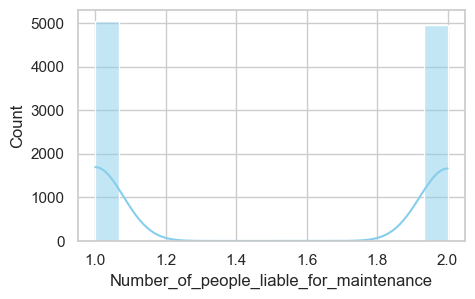

In [151]:
sns.histplot(data=df, x="Number_of_people_liable_for_maintenance", kde=True, color="skyblue")

🎯 Overall Dataset Insights
✔ Highly variable numerical values (Credit amount, Income)

→ Must be normalized for ML models.

✔ Several columns are categorical-discrete (1–4)

→ Should be encoded as categories, not treated as continuous.

✔ No missing values

→ Good for training ML models.

✔ Some columns show skewed distribution

→ May require log transformation (Income, Credit Amount).

In [159]:
target = "Credit_Risk"

<Axes: xlabel='Credit_Risk', ylabel='Duration_in_month'>

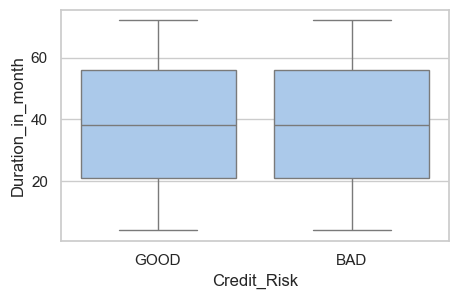

In [167]:
sns.boxplot(data=df, x=target, y="Duration_in_month")

In [684]:
# num_cols = df.select_dtypes(include=np.number).columns
corr = df[['Duration_in_month','Credit_amount', 'Annual Income (PKR)']].corr()
corr

,Duration_in_month,Credit_amount,Annual Income (PKR)
Duration_in_month,1.000000,-0.009667,0.013886
Credit_amount,-0.009667,1.000000,-0.017133
Annual Income (PKR),0.013886,-0.017133,1.000000


In [752]:
df = bank.copy()

In [754]:
X = df.iloc[:,1:22]
y = df.iloc[:,-1]

In [756]:
from sklearn.model_selection import train_test_split

In [758]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [760]:
print(X_train.shape)
print(X_test.shape)

(8000, 21)
(2000, 21)


In [762]:
df.shape

(10000, 23)

In [764]:
X_train.drop(columns=["Present_employment_since", "Duration_in_month","Credit_amount"], inplace=True)
X_test.drop(columns=["Present_employment_since", "Duration_in_month","Credit_amount"], inplace=True)

In [766]:
X_test.shape

(2000, 18)

In [716]:
cat_cols = [
    "Purpose",
    "marital status",
    "gender",
    "Property",
    "Other_installment_plans",
    "Housing",
    "Credit_history",
    "Savings_account_bonds",
    "Other_debtors_guarantors",
    "Job Category",
    "Status_of_existing_checking_account"
]
cat_col_indexs = [
    X_train.columns.get_loc(col)
    for col in cat_cols
]
cat_col_indexs

[2, 6, 5, 9, 11, 12, 1, 3, 7, 14, 0]

In [730]:
num_cols = [
    "Age_in_years",
    "Annual Income (PKR)"
]
num_col_indexs = [
    X_train.columns.get_loc(col)
    for col in num_cols
]
print(num_col_indexs)
print(X_train.columns[num_col_indexs])

[10, 16]
Index(['Age_in_years', 'Annual Income (PKR)'], dtype='object')


In [720]:
ordinal_cols = [
    "Income Level",
    "Installment_rate_percent_income",
    "Number_of_existing_credits_at_this_bank",
    "Number_of_people_liable_for_maintenance"   
]
ord_col_indexes = [
    X_train.columns.get_loc(col)
    for col in ordinal_cols
]
ord_col_indexes

[15, 4, 13, 17]

In [810]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.decomposition import PCA

pca = PCA(n_components=10)


# Column index groups
num_col_indexes = [10, 16]
cat_col_indexes = [2, 6, 5, 9, 11, 12, 1, 3, 7, 14, 0]
ord_col_indexes = [15, 4, 13, 17]

# Define preprocessing for each type
preprocessor = ColumnTransformer(
    transformers=[
        ("pt", PowerTransformer(method="box-cox"), num_col_indexes),
        ("age_scale", StandardScaler(), [10]),
        ("incom_robust", RobustScaler(), [16]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_col_indexes),
        ("ord", OrdinalEncoder(), ord_col_indexes)
    ]
)

# ft = FunctionTransformer(np.log1p)
# month_transformed = ft.transform([4,19])

# Full pipeline

rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=8,
    max_features= 0.6,
    max_samples= 1.0,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42)

lr = LogisticRegression()

dt = DecisionTreeClassifier()

svc = SVC()

gb = GradientBoostingClassifier()

knn = KMeans(n_clusters=2)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    # ("scale",SelectKBest(score_func=mutual_info_classif, k=15)),
    ("classifier", dt)
])

le = LabelEncoder()
y_train_transformed = le.fit_transform(y_train)
y_test_transformed = le.transform(y_test)

# Fit the pipeline
pipe.fit(X_train, y_train_transformed)

ValueError: not enough values to unpack (expected 3, got 2)

In [770]:
y_pred = pipe.predict(X_test)

In [772]:
from sklearn.metrics import accuracy_score
print("Accuracy Score Random Forest Pipe: {}".format(accuracy_score(y_test_transformed, y_pred)))

Accuracy Score Random Forest Pipe: 0.4945


In [738]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(pipe, X_train, y_train_transformed, cv=10, scoring="accuracy"))

0.5015

In [782]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

df2 = df.copy()
y = df2["Credit_Risk"]
X = df2.drop(["Credit_Risk","Client_ID"], axis=1)

# Identify categorical features
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

model = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    l2_leaf_reg=5,
    random_strength=1.5,
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=50
)

# ✅ Train using Pool (correct)
model.fit(train_pool, eval_set=test_pool)

print("Train Score:", model.score(train_pool))
print("Test Score:", model.score(test_pool))

0:	learn: 0.5090000	test: 0.5115000	best: 0.5115000 (0)	total: 47.7ms	remaining: 14.3s
50:	learn: 0.5393750	test: 0.5195000	best: 0.5300000 (42)	total: 1.81s	remaining: 8.83s
100:	learn: 0.5567500	test: 0.5035000	best: 0.5300000 (42)	total: 3.4s	remaining: 6.7s
150:	learn: 0.5625000	test: 0.5095000	best: 0.5300000 (42)	total: 5.15s	remaining: 5.08s
200:	learn: 0.5873750	test: 0.5115000	best: 0.5300000 (42)	total: 7.13s	remaining: 3.51s
250:	learn: 0.6187500	test: 0.5110000	best: 0.5300000 (42)	total: 9.17s	remaining: 1.79s
299:	learn: 0.6383750	test: 0.5160000	best: 0.5300000 (42)	total: 11.2s	remaining: 0us

bestTest = 0.53
bestIteration = 42

Shrink model to first 43 iterations.
Train Score: 0.519125
Test Score: 0.53


In [784]:
y.value_counts(normalize=True)

Credit_Risk
GOOD    0.5021
BAD     0.4979
Name: proportion, dtype: float64

In [792]:
# Required Libraries
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from catboost import CatBoostClassifier

# Example dataset
# df = pd.read_csv("your_data.csv")
# target = 'target_column'
X = df.drop(columns=target)
y = df[target]

# Identify categorical and numerical features
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Convert numeric categorical features to string
for col in cat_features:
    X[col] = X[col].astype(str)

# Numeric pipeline: impute missing + optional power transform + scaling
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(method='yeo-johnson', standardize=True))
])

# Categorical pipeline: impute missing + convert to string
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Full preprocessing
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() < 10 else None
)

# Preprocess training data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Get indices of categorical features in the preprocessed data
cat_feature_indices = list(range(len(num_features), X_train_proc.shape[1]))

# CatBoost classifier
cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

# Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', cat_model)
])

# Fit the model
pipeline.named_steps['model'].fit(
    X_train_proc, 
    y_train, 
    cat_features=cat_feature_indices,
    eval_set=(X_test_proc, y_test)
)

# Predictions
y_pred = pipeline.predict(X_test_proc)
y_pred_proba = pipeline.predict_proba(X_test_proc)[:,1]

# Optional: Hyperparameter tuning
param_grid = {
    'model__depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.03, 0.05],
    'model__iterations': [500, 1000, 2000]
}

grid_search = GridSearchCV(
    pipeline, param_grid, cv=3, scoring='roc_auc' if y.nunique() < 10 else 'r2', n_jobs=-1
)
grid_search.fit(X_train_proc, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

0:	test: 0.5084611	best: 0.5084611 (0)	total: 38.7ms	remaining: 1m 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5293879702
bestIteration = 12

Shrink model to first 13 iterations.


ValueError: Specifying the columns using strings is only supported for dataframes.

In [806]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


# Load data
df = pd.read_excel("Bank_updated.xlsx")  # replace with your file
X = df.drop(columns=["Credit_Risk","Client_ID"])
y = df["Credit_Risk"]

# Preprocessing
numeric_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])



models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200),
    "GradientBoosting": GradientBoostingClassifier()
}



# Full pipeline
results = []
for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),  # same ColumnTransformer
        ("selector", SelectKBest(mutual_info_classif, k=10)),
        ("classifier", GradientBoostingClassifier())
    ])
    pipe.fit(X_train, y_train)
y_pred_proba = pipe.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

ROC-AUC: 0.4996029936478984


<Axes: xlabel='Duration_in_month_boxcox', ylabel='Count'>

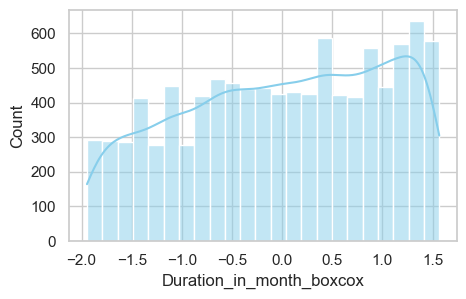

In [69]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method="box-cox")
month_transformed = pt.fit_transform(df[["Duration_in_month"]])
df["Duration_in_month_boxcox"] = month_transformed.flatten()
sns.histplot(data=df, x="Duration_in_month_boxcox", kde=True, color="skyblue")

<Axes: xlabel='Duration_in_month_yeojohnson', ylabel='Count'>

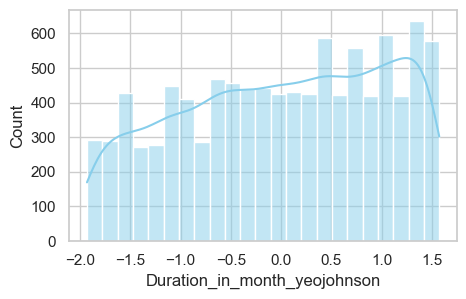

In [71]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
month_transformed = pt.fit_transform(df[["Duration_in_month"]])
df["Duration_in_month_yeojohnson"] = month_transformed.flatten()
sns.histplot(data=df, x="Duration_in_month_yeojohnson", kde=True, color="skyblue")

<Axes: xlabel='Duration_in_month_log', ylabel='Count'>

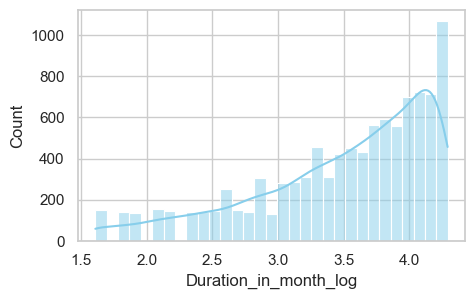

In [84]:
from sklearn.preprocessing import FunctionTransformer
ft = FunctionTransformer(np.log1p)
month_transformed = ft.transform(df[["Duration_in_month"]])
df["Duration_in_month_log"] = month_transformed
sns.histplot(data=df, x="Duration_in_month_log", kde=True, color="skyblue")